In [1]:
import sqlite3


In [2]:
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

In [3]:
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [5]:
sales_data = [
    ('Product A', 10, 20.0),
    ('Product B', 5, 15.0),
    ('Product A', 8, 20.0),
    ('Product C', 7, 10.0),
    ('Product B', 3, 15.0),
    ('Product B', 4, 20.0)
]

In [6]:
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)


In [8]:
conn.commit()
print("Database and table created, data inserted successfully.")

Database and table created, data inserted successfully.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

In [11]:
df = pd.read_sql_query(query, conn)

In [12]:
print("Sales Summary:")
print(df)

Sales Summary:
     product  total_qty  revenue
0  Product A         18    360.0
1  Product B         12    200.0
2  Product C          7     70.0


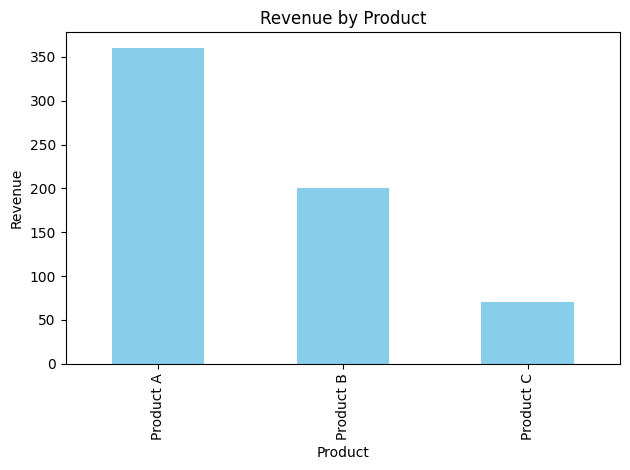

In [14]:
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()

In [15]:
plt.savefig("sales_chart.png")

plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
conn.close()
print("Connection closed.")

Connection closed.
